In [2]:
# y_hat = model(x)
# order = strategy(y_hat)
# execute(orders)

# regression model => BTCUSDT => future log return

In [3]:
import sys
print(sys.executable)

/home/jaden/Projects/Research/.venv/bin/python


In [4]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random

# Machine learning libraries
import torch                                # Pytorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities

# Visualization
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [5]:
research.set_seed(42)

In [6]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [7]:
# Trading pair symbol
sym = 'BTCUSDT'
# Historical data window in days (e.g., 6 months)
hist_data_window = 7 * 4 * 6
# time horizon of time series (time interval)
time_interval = '1h'
# max number of auto-regresive lags
max_lags = 4
# Forcase horizon in steps
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [8]:
print(binance.__file__)
print(hasattr(binance, "download_trades"))

/home/jaden/Projects/Research/binance.py
True


In [9]:
binance.download_trades(sym, hist_data_window)

In [10]:
ts = research.load_ohlc_timeseries(sym, time_interval)
ts

Loading BTCUSDT: 100%|██████████| 169/169 [00:56<00:00,  2.99file/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0
…,…,…,…,…
2026-07-13 19:00:00,61997.4,62267.0,61962.5,62258.0
2026-07-13 20:00:00,62257.9,62299.0,62020.0,62179.3
2026-07-13 21:00:00,62179.3,62192.1,61868.0,62034.1


In [11]:
research.load_timeseries(sym, time_interval, pl.col('price').quantile(0.5).alias('price_median'))

Loading BTCUSDT: 100%|██████████| 169/169 [00:43<00:00,  3.92file/s]


datetime,price_median
datetime[μs],f64
2026-01-26 00:00:00,86828.9
2026-01-26 01:00:00,87538.0
2026-01-26 02:00:00,87605.4
2026-01-26 03:00:00,87358.7
2026-01-26 04:00:00,87719.9
…,…
2026-07-13 19:00:00,62076.0
2026-07-13 20:00:00,62169.4
2026-07-13 21:00:00,62006.8


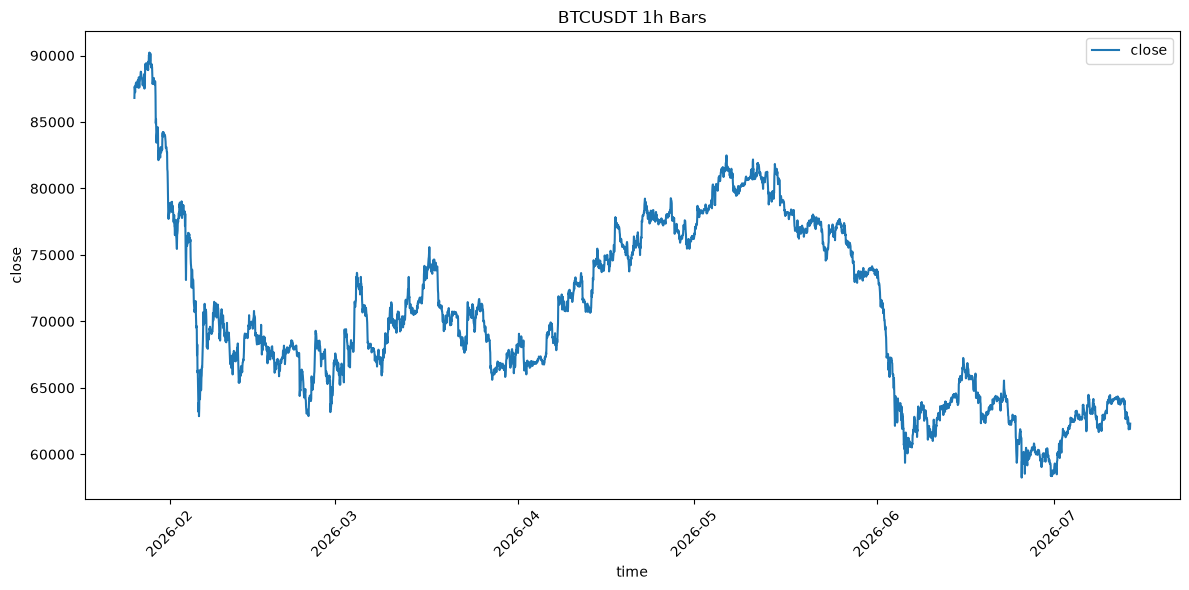

In [12]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [13]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

## Feature Engineering

In [14]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [15]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [16]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4,null
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8,0.009783
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8,-0.001678
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1,-0.003224
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0,0.005338
…,…,…,…,…,…
2026-07-13 19:00:00,61997.4,62267.0,61962.5,62258.0,0.004196
2026-07-13 20:00:00,62257.9,62299.0,62020.0,62179.3,-0.001265
2026-07-13 21:00:00,62179.3,62192.1,61868.0,62034.1,-0.002338


In [17]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4,null,null,null,null,null
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8,0.009783,null,null,null,null
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8,-0.001678,0.009783,null,null,null
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1,-0.003224,-0.001678,0.009783,null,null
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0,0.005338,-0.003224,-0.001678,0.009783,null
…,…,…,…,…,…,…,…,…,…
2026-07-13 19:00:00,61997.4,62267.0,61962.5,62258.0,0.004196,0.001942,-0.006138,-0.005424,-0.002771
2026-07-13 20:00:00,62257.9,62299.0,62020.0,62179.3,-0.001265,0.004196,0.001942,-0.006138,-0.005424
2026-07-13 21:00:00,62179.3,62192.1,61868.0,62034.1,-0.002338,-0.001265,0.004196,0.001942,-0.006138


In [18]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4,null,null,null,null,null
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8,0.009783,null,null,null,null
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8,-0.001678,0.009783,null,null,null
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1,-0.003224,-0.001678,0.009783,null,null
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0,0.005338,-0.003224,-0.001678,0.009783,null
…,…,…,…,…,…,…,…,…,…
2026-07-13 19:00:00,61997.4,62267.0,61962.5,62258.0,0.004196,0.001942,-0.006138,-0.005424,-0.002771
2026-07-13 20:00:00,62257.9,62299.0,62020.0,62179.3,-0.001265,0.004196,0.001942,-0.006138,-0.005424
2026-07-13 21:00:00,62179.3,62192.1,61868.0,62034.1,-0.002338,-0.001265,0.004196,0.001942,-0.006138


In [19]:
ts = ts.drop_nulls()

In [20]:
research.plot_distribution(ts, target, no_bins=100)

alt.Chart(...)

In [21]:
research.plot_distribution(ts, 'close', no_bins=100)

alt.Chart(...)

### Build Model

In [22]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [23]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

In [24]:
# y = w * x + b

### Split by time

In [25]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [26]:
len(ts)

4051

In [27]:
int(len(ts) * test_size)

1012

In [28]:
split_idx = int(len(ts) * (1-test_size))
split_idx

3038

In [29]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [30]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-26 05:00:00,87699.9,87919.0,87617.1,87776.4,0.000871,0.005338,-0.003224,-0.001678,0.009783
2026-01-26 06:00:00,87776.5,87999.0,87705.8,87902.6,0.001437,0.000871,0.005338,-0.003224,-0.001678
2026-01-26 07:00:00,87902.7,88059.6,87665.6,87968.9,0.000754,0.001437,0.000871,0.005338,-0.003224
2026-01-26 08:00:00,87969.0,88367.5,87800.0,87947.3,-0.000246,0.000754,0.001437,0.000871,0.005338
2026-01-26 09:00:00,87947.4,87968.4,87556.9,87630.4,-0.00361,-0.000246,0.000754,0.001437,0.000871
…,…,…,…,…,…,…,…,…,…
2026-06-01 14:00:00,71698.8,71884.9,71387.6,71548.5,-0.002097,-0.006872,-0.003591,-0.003762,-0.001776
2026-06-01 15:00:00,71548.5,71662.6,71035.3,71099.4,-0.006297,-0.002097,-0.006872,-0.003591,-0.003762
2026-06-01 16:00:00,71099.5,71600.0,70650.9,71537.7,0.006146,-0.006297,-0.002097,-0.006872,-0.003591


In [31]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-06-01 19:00:00,71470.1,71645.2,71358.0,71571.0,0.001411,-0.002066,0.00112,0.006146,-0.006297
2026-06-01 20:00:00,71571.0,71670.0,71383.8,71419.8,-0.002115,0.001411,-0.002066,0.00112,0.006146
2026-06-01 21:00:00,71419.7,71419.8,70911.0,71004.6,-0.00583,-0.002115,0.001411,-0.002066,0.00112
2026-06-01 22:00:00,71004.6,71439.5,70806.0,71376.6,0.005225,-0.00583,-0.002115,0.001411,-0.002066
2026-06-01 23:00:00,71376.7,71564.0,71199.0,71391.5,0.000209,0.005225,-0.00583,-0.002115,0.001411
…,…,…,…,…,…,…,…,…,…
2026-07-13 19:00:00,61997.4,62267.0,61962.5,62258.0,0.004196,0.001942,-0.006138,-0.005424,-0.002771
2026-07-13 20:00:00,62257.9,62299.0,62020.0,62179.3,-0.001265,0.004196,0.001942,-0.006138,-0.005424
2026-07-13 21:00:00,62179.3,62192.1,61868.0,62034.1,-0.002338,-0.001265,0.004196,0.001942,-0.006138


In [32]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)

In [33]:
X_train

tensor([[ 0.0053],
        [ 0.0009],
        [ 0.0014],
        ...,
        [-0.0063],
        [ 0.0061],
        [ 0.0011]])

In [34]:
X_train.shape

torch.Size([3038, 1])

In [35]:
y_train

tensor([ 0.0009,  0.0014,  0.0008,  ...,  0.0061,  0.0011, -0.0021])

In [36]:
y_train.shape

torch.Size([3038])

In [37]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[ 0.0009],
        [ 0.0014],
        [ 0.0008],
        ...,
        [ 0.0061],
        [ 0.0011],
        [-0.0021]])

In [38]:
y_train.shape

torch.Size([3038, 1])

In [39]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[ 0.0014],
        [-0.0021],
        [-0.0058],
        ...,
        [-0.0023],
        [-0.0022],
        [ 0.0066]])

In [40]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 0.0053],
         [ 0.0009],
         [ 0.0014],
         ...,
         [-0.0063],
         [ 0.0061],
         [ 0.0011]]),
 tensor([[-0.0021],
         [ 0.0014],
         [-0.0021],
         ...,
         [-0.0013],
         [-0.0023],
         [-0.0022]]),
 tensor([[ 0.0009],
         [ 0.0014],
         [ 0.0008],
         ...,
         [ 0.0061],
         [ 0.0011],
         [-0.0021]]),
 tensor([[ 0.0014],
         [-0.0021],
         [-0.0058],
         ...,
         [-0.0023],
         [-0.0022],
         [ 0.0066]]))

### Batch Gradient Descent

In [41]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# loss function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")



Training model...
Epoch [500/5000], Loss: 0.469067
Epoch [1000/5000], Loss: 0.234753
Epoch [1500/5000], Loss: 0.101813
Epoch [2000/5000], Loss: 0.036188
Epoch [2500/5000], Loss: 0.009772
Epoch [3000/5000], Loss: 0.001828
Epoch [3500/5000], Loss: 0.000227
Epoch [4000/5000], Loss: 0.000037
Epoch [4500/5000], Loss: 0.000026
Epoch [5000/5000], Loss: 0.000025

Learned parameters
linear.weight:
[[0.03020536]]
linear.bias:
[-1.698806e-05]

Test Loss: 0.000028, Train Loss: 0.000025
